In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# code to generate segmentation using cityscapes pretrained modelsplt

import cv2
import numpy as np
from PIL import Image
import torch
import functools
from enum import Enum
import matplotlib.pyplot as plt



class MapillaryLabelCls(Enum):
    BIRD = 0
    GROUND_ANIMAL = 1
    CURB = 2
    FENCE = 3
    GUARD_RAIL = 4
    BARRIER = 5
    WALL = 6
    BIKE_LANE = 7
    CROSSWALK_PLAIN = 8
    CURB_CUT = 9
    PARKING = 10
    PEDESTRIAN_AREA = 11
    RAIL_TRACK = 12
    ROAD = 13
    SERVICE_LANE = 14
    SIDEWALK = 15
    BRIDGE = 16
    BUILDING = 17
    TUNNEL = 18
    PERSON = 19
    BICYCLIST = 20
    MOTORCYCLIST = 21
    OTHER_RIDER = 22
    LANE_MARKING_CROSSWALK = 23
    LANE_MARKING_GENERAL = 24
    MOUNTAIN = 25
    SAND = 26
    SKY = 27
    SNOW = 28
    TERRAIN = 29
    VEGETATION = 30
    WATER = 31
    BANNER = 32
    BENCH = 33
    BIKE_RACK = 34
    BILLBOARD = 35
    CATCH_BASIN = 36
    CCTV_CAMERA = 37
    FIRE_HYDRANT = 38
    JUNCTION_BOX = 39
    MAILBOX = 40
    MANHOLE = 41
    PHONE_BOOTH = 42
    POTHOLE = 43
    STREET_LIGHT = 44
    POLE = 45
    TRAFFIC_SIGN_FRAME = 46
    UTILITY_POLE = 47
    TRAFFIC_LIGHT = 48
    TRAFFIC_SIGN_BACK = 49
    TRAFFIC_SIGN_FRONT = 50
    TRASH_CAN = 51
    BICYCLE = 52
    BOAT = 53
    BUS = 54
    CAR = 55
    CARAVAN = 56
    MOTORCYCLE = 57
    ON_RAILS = 58
    OTHER_VEHICLE = 59
    TRAILER = 60
    TRUCK = 61
    WHEELED_SLOW = 62
    CAR_MOUNT = 63
    EGO_VEHICLE = 64

@functools.lru_cache(maxsize=1)
def get_cached_seg_former() -> "SegFormerMapillary":
    return SegFormerMapillary()


@functools.lru_cache(maxsize=40)
def cached_predict(img_path) -> np.ndarray:
    model = get_cached_seg_former()
    return model.predict(img_path)


class SegFormerMapillary:
    """
    example usage:
        model = SegFormerMapillary()
        pred = model.predict(<image-path>)
        road = model.get_mask(pred, CityScapesCls.ROAD)

        # simple numpy mask, you can overlay now
        orig = cv2.imread(<image-path>)
        # mark road as red, bgr
        orig[road] = [0, 0, 255]
        cv2.imshow(orig)
    """

    def __init__(self):
        # from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation
        from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

        processor = AutoImageProcessor.from_pretrained(
            "facebook/mask2former-swin-large-mapillary-vistas-semantic", use_fast=True
        )
        model = Mask2FormerForUniversalSegmentation.from_pretrained(
            "facebook/mask2former-swin-large-mapillary-vistas-semantic"
        )
        self.processor = processor
        self.model = model

    def _predict(self, pil_image):
        img = pil_image
        orig = np.array(img)
        h, w, _ = orig.shape

        inputs = self.processor(images=img, return_tensors="pt")

        with torch.no_grad():
            outputs = self.model(**inputs)

        class_queries_logits = outputs.class_queries_logits
        masks_queries_logits = outputs.masks_queries_logits
        print("class query logits", class_queries_logits)
        print("mask query logits", masks_queries_logits)

        # you can pass them to processor for postprocessing
        predicted_semantic_map = self.processor.post_process_semantic_segmentation(
            outputs, target_sizes=[img.size[::-1]]
        )[0]
        return predicted_semantic_map

        # logits = torch.nn.functional.interpolate(
        #     outputs.logits, size=(h, w), mode="bilinear", align_corners=False
        # )

        # return torch.argmax(logits, dim=1)[0].cpu().numpy()

    def predict_bgr_image(self, img):
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self._predict(Image.fromarray(img))

    def predict(self, img_path):
        img = Image.open(img_path).convert("RGB")
        return self._predict(img)

    def get_mask(pred, lbl: MapillaryLabelCls):
        return pred == lbl.value


def get_mask(pred, lbl: MapillaryLabelCls):
    return pred == lbl.value


def get_mask_with_labels(pred, lbls: list[MapillaryLabelCls]):
    mask = np.zeros_like(pred, dtype=bool)
    for lbl in lbls:
        mask |= pred == lbl.value
    return mask


def show_seg_mask(mask):
    label_by_name = {mem.value: mem.name for mem in MapillaryLabelCls}
    plt.figure(figsize=(5, 5))
    im = plt.imshow(mask, cmap="tab20", interpolation="nearest")
    plt.colorbar(im, ticks=np.unique(mask))
    plt.title("Segmentation Mask")
    plt.axis("off")
    plt.show()
    for k, v in label_by_name.items():
        print(f"{k:>20} -> {v}")


In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random

IMAGES = list(Path('../../datasets/positive-samples').glob("*.jpg"))

In [5]:
model = SegFormerMapillary()

In [7]:
res = model.predict(IMAGES[0]).numpy()

class query logits tensor([[[-5.1531, -8.2496, -2.0706,  ..., -7.2523, -5.0575,  8.6576],
         [-3.0542, -5.0013, -4.5676,  ..., -5.0046, -4.2171,  8.0948],
         [-5.7896, -9.5325, -4.1867,  ..., -7.1286, -5.6169,  9.0841],
         ...,
         [-2.9685, -2.1070, -3.5438,  ...,  2.4834,  3.7828,  7.5428],
         [-1.6936, -0.3192, -0.8470,  ..., -1.0292, -1.7554,  2.3509],
         [-4.6295, -6.4146, -4.2220,  ..., -6.1967, -4.8448,  8.4113]]])
mask query logits tensor([[[[ -35.4389,  -38.9634,  -37.2203,  ...,  -30.3249,  -33.7862,
            -31.4597],
          [ -34.9543,  -30.6375,  -29.3232,  ...,  -32.8776,  -35.5719,
            -36.4272],
          [ -32.4307,  -29.0183,  -28.2749,  ...,  -32.6026,  -35.5803,
            -36.4965],
          ...,
          [ -24.7526,  -23.4874,  -21.0196,  ...,  -21.6617,  -24.8875,
            -17.4358],
          [ -23.8528,  -23.0063,  -21.0233,  ...,  -24.5589,  -23.9171,
            -18.6307],
          [ -29.4801,  -26.4040

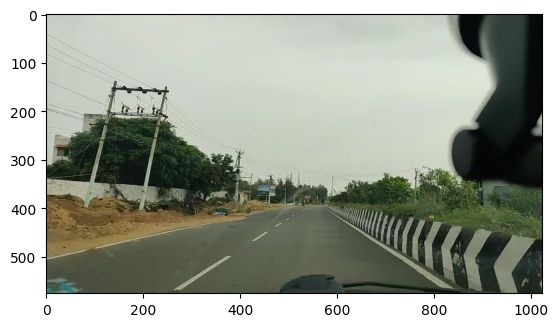

In [8]:
plt.imshow(plt.imread(IMAGES[0]))

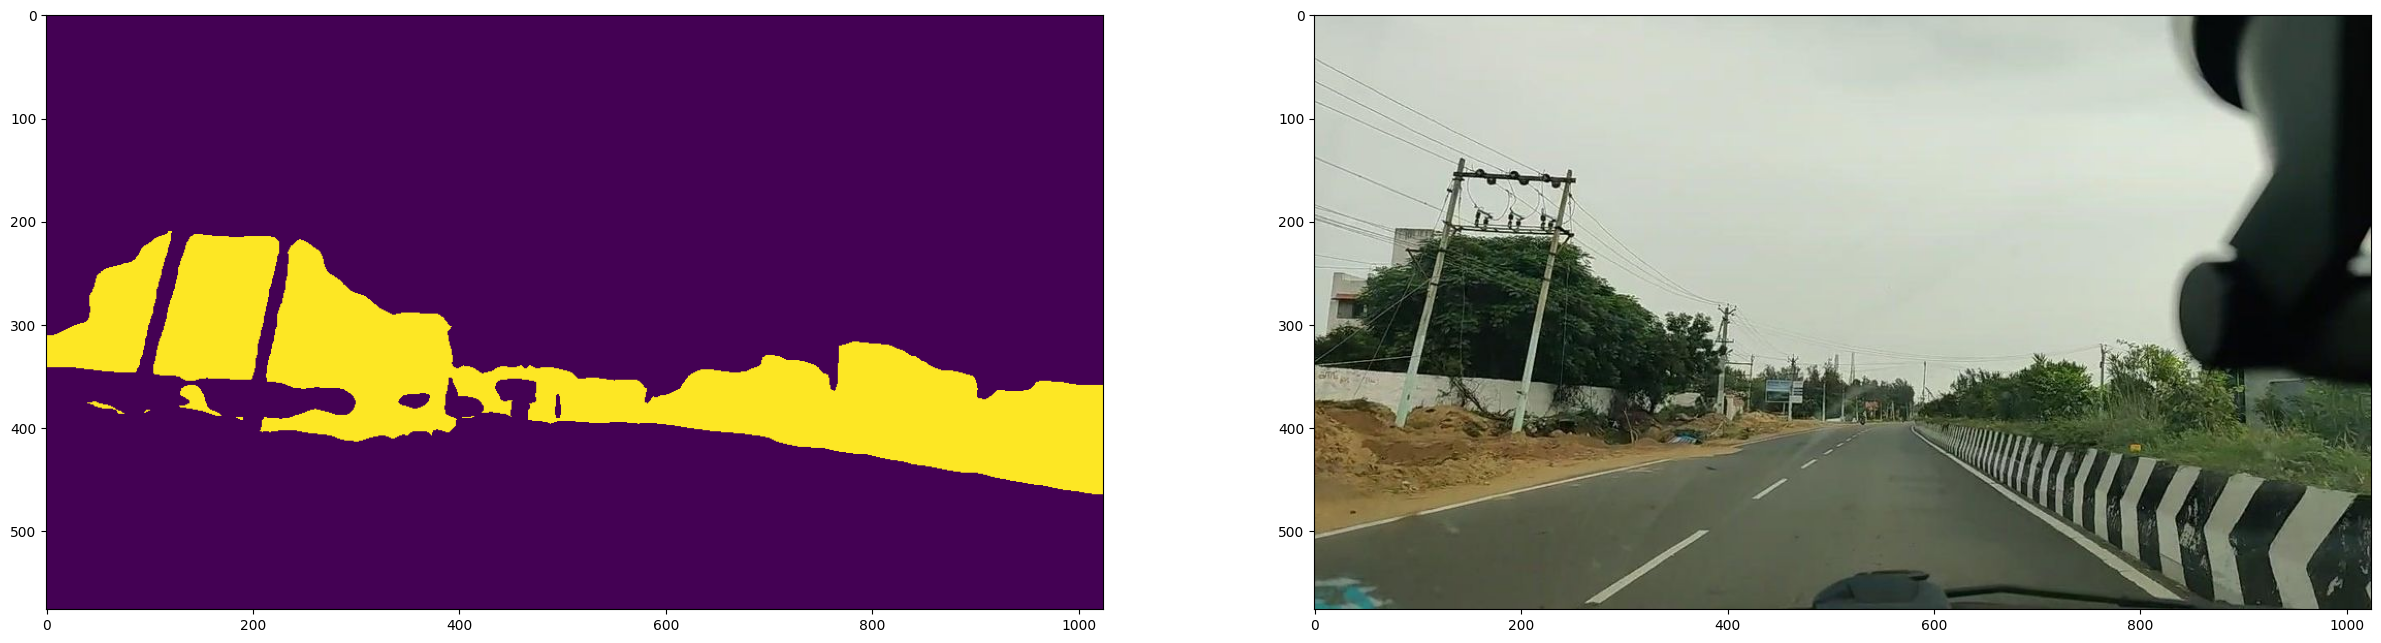

In [9]:
mask = get_mask_with_labels(res, [
    MapillaryLabelCls.VEGETATION,
])
_, ax = plt.subplots(1, 2, figsize=(30,20))
ax[0].imshow(mask)
ax[1].imshow(plt.imread(IMAGES[0]))
plt.show()

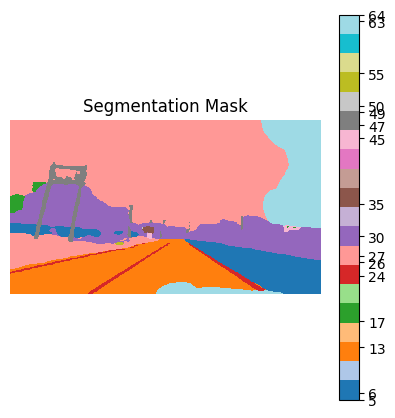

                   0 -> BIRD
                   1 -> GROUND_ANIMAL
                   2 -> CURB
                   3 -> FENCE
                   4 -> GUARD_RAIL
                   5 -> BARRIER
                   6 -> WALL
                   7 -> BIKE_LANE
                   8 -> CROSSWALK_PLAIN
                   9 -> CURB_CUT
                  10 -> PARKING
                  11 -> PEDESTRIAN_AREA
                  12 -> RAIL_TRACK
                  13 -> ROAD
                  14 -> SERVICE_LANE
                  15 -> SIDEWALK
                  16 -> BRIDGE
                  17 -> BUILDING
                  18 -> TUNNEL
                  19 -> PERSON
                  20 -> BICYCLIST
                  21 -> MOTORCYCLIST
                  22 -> OTHER_RIDER
                  23 -> LANE_MARKING_CROSSWALK
                  24 -> LANE_MARKING_GENERAL
                  25 -> MOUNTAIN
                  26 -> SAND
                  27 -> SKY
                  28 -> SNOW
                  29 

In [24]:
show_seg_mask(res)

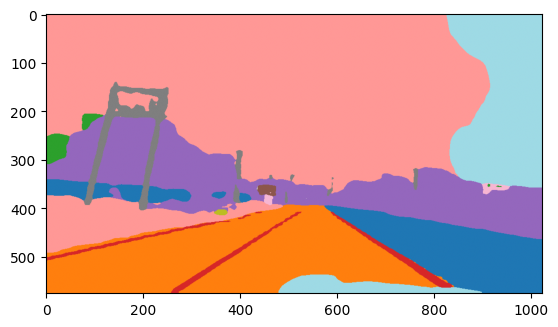

In [13]:
plt.imshow(res, cmap="tab20")